<h1 align='center'>Machine Learning Model for Natural Language Processing (NLP) - Sentiment Analysis</h1>
<hr size=10 color='orange'>
<h2 align='center'>ISY503 Intelligent Systems - Assessment 3 (Individual)</h2>

**Author:** Jhonatan Mosquera Caro - A00172611  
**Subject:** ISY503 Intelligent Systems - Torrens University Australia  
**Dataset:** Multi-Domain Sentiment Dataset (Blitzer et al., 2007)  
**Reference:** http://www.cs.jhu.edu/~mdredze/datasets/sentiment/index2.html

---

# Table of Contents
* [1. Loading Libraries](#c1)
* [2. Exploratory Data Analysis](#c2)
* [3. Data Pre-Processing](#c3)
* [4. Neural Network Model - MLP](#c4)
* [5. Logistic Regression - Comparison Model](#c5)
* [6. Model Testing with New Entry Data](#c6)
* [7. Ethical Considerations](#c7)

<a name='c1'></a>
# 1. Loading Libraries

Before running this notebook:
1. Go to **[drive.google.com](https://drive.google.com)**
2. Upload **`Multi_Domain_Sentiment_Dataset.zip`** to your Google Drive root folder
3. Run all cells in order

In [1]:
# install packages
!pip install beautifulsoup4 html5lib wordcloud autocorrect -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 622.8/622.8 kB 3.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [2]:
# connect to google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# unzip the dataset
!unzip -q "/content/drive/MyDrive/Multi_Domain_Sentiment_Dataset.zip" -d /content/
print('done')
!ls /content/Multi_Domain_Sentiment_Dataset-main/sorted_data_acl/

done
books  dvd


In [4]:
# import all libraries
from bs4 import BeautifulSoup
import numpy as np
import pandas as pd
from wordcloud import WordCloud
import matplotlib.pyplot as plt
import seaborn as sns
from autocorrect import Speller
spell = Speller(lang='en')
import string
import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('words', quiet=True)
nltk.download('brown', quiet=True)
from nltk.stem import WordNetLemmatizer
from nltk.corpus import brown, stopwords
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import MaxAbsScaler

print('libraries loaded')

libraries loaded


In [5]:
# load the reviews using beautifulsoup to parse the xml files
positive_reviews = BeautifulSoup(
    open('/content/Multi_Domain_Sentiment_Dataset-main/sorted_data_acl/books/positive.review').read(),
    features='html5lib'
)
positive_reviews = positive_reviews.find_all('review_text')
positive_reviews = [i.get_text(strip=True) for i in positive_reviews if i.get_text(strip=True)]

negative_reviews = BeautifulSoup(
    open('/content/Multi_Domain_Sentiment_Dataset-main/sorted_data_acl/books/negative.review').read(),
    features='html5lib'
)
negative_reviews = negative_reviews.find_all('review_text')
negative_reviews = [i.get_text(strip=True) for i in negative_reviews if i.get_text(strip=True)]

print(f'positive: {len(positive_reviews)}')
print(f'negative: {len(negative_reviews)}')
print(f'\nsample positive:\n{positive_reviews[0][:300]}')
print(f'\nsample negative:\n{negative_reviews[0][:300]}')

positive: 1000
negative: 1000

sample positive:
Sphere by Michael Crichton is an excellant novel. This was certainly the hardest to put down of all of the Crichton novels that I have read. 

The story revolves around a man named Norman Johnson. Johnson is a phycologist. He travels with 4 other civilans to a remote location in the Pacific Ocean to

sample negative:
THis book was horrible.  If it was possible to rate it lower than one star i would have.  I am an avid reader and picked this book up after my mom had gotten it from a friend.  I read half of it, suffering from a headache the entire time, and then got to the part about the relationship the 13 year o


In [6]:
# combine into dataframe
# label encoding: 1 = positive, 0 = negative
data = {
    'Text': positive_reviews + negative_reviews,
    'Sentiment': [1] * len(positive_reviews) + [0] * len(negative_reviews)
}
df = pd.DataFrame(data=data)

# shuffle to remove ordering bias
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print(df.shape)
df.head()

(2000, 2)


,Text,Sentiment
0,Can anyone tell me if the book words on the vi...,0
1,I have read all of Van Gulik's murder mysterie...,1
2,There are two things which tickle me about thi...,0
3,John Little and Peter Sisco wrote static contr...,1
4,it is juust a copy of the frist book. if you r...,0


<a name='c2'></a>
# 2. Exploratory Data Analysis

Before building the model, the dataset is explored to understand the distribution of review lengths, check class balance, and identify any issues that need to be addressed during preprocessing.

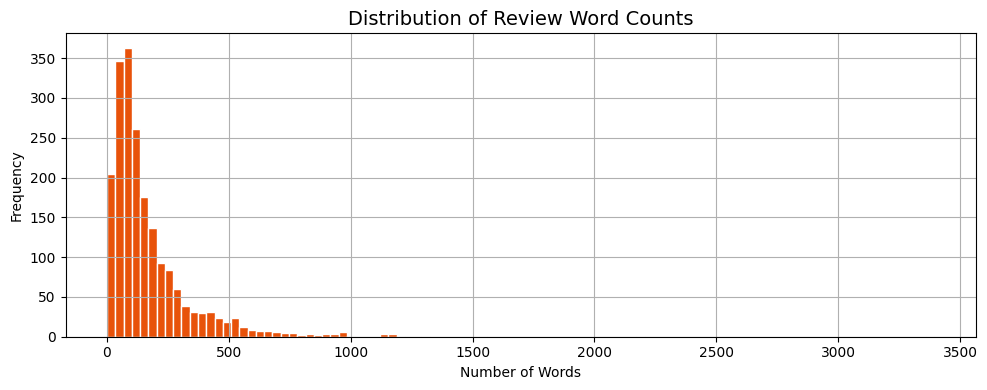

mean: 172.8
std : 194.0
min : 1
max : 3393


In [7]:
# word count distribution
N_words = df.Text.apply(lambda x: len(x.split()))

plt.figure(figsize=(10, 4))
N_words.hist(bins=100, color='#E8520A', edgecolor='white')
plt.title('Distribution of Review Word Counts', fontsize=14)
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

print('mean: ' + str(round(N_words.mean(), 1)))
print('std : ' + str(round(N_words.std(), 1)))
print('min : ' + str(N_words.min()))
print('max : ' + str(N_words.max()))

In [8]:
# check for very short reviews, these are flagged for outlier removal
df1 = df.copy()
df1['N_words'] = N_words
print('Reviews with fewer than 3 words:')
df1[df1.N_words < 3]

Reviews with fewer than 3 words:


,Text,Sentiment,N_words
1544,Period,1,1


Sentiment
0    1000
1    1000
Name: count, dtype: int64


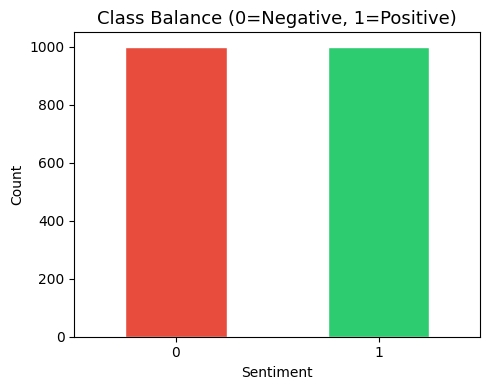

In [9]:
# class balance check
# equal classes = no imbalance bias
Sentiment_count = df.Sentiment.value_counts()
print(Sentiment_count)

plt.figure(figsize=(5, 4))
Sentiment_count.plot(kind='bar', color=['#E74C3C', '#2ECC71'], edgecolor='white')
plt.title('Class Balance (0=Negative, 1=Positive)', fontsize=13)
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

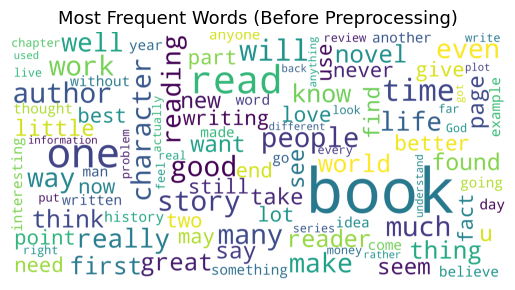

In [10]:
# word cloud before cleaning
Words_cloud = ' '.join(df.Text)
wordcloud = WordCloud(
    max_font_size=100, max_words=100,
    background_color='white', scale=10, width=800, height=400
).generate(Words_cloud)

plt.figure()
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Frequent Words (Before Preprocessing)', fontsize=13)
plt.show()

<a name='c3'></a>
# 3. Data Pre-Processing

The following steps are applied as required by the assessment brief:
- **Clean** the text (lowercase, remove punctuation, digits, correct spelling)
- **Encode** the words using CountVectorizer
- **Encode** the labels (1 = positive, 0 = negative, done during data loading)
- **Outlier removal** - remove reviews that are too short or too long
- **Pad / truncate** - standardise feature vector length using MaxAbsScaler
- **Split** into training, validation and test sets
- **Batches** - generate batches of training data using a generator function

In [11]:
# step 1 outlier removal
# remove reviews that are too short (ambiguous) or too long (outliers)
MIN_WORDS = 3
MAX_WORDS = 500

df['N_words'] = df.Text.apply(lambda x: len(x.split()))
before = len(df)
df = df[(df.N_words >= MIN_WORDS) & (df.N_words <= MAX_WORDS)].reset_index(drop=True)
after = len(df)

print(f'Outlier removal: {before} -> {after} reviews ({before - after} removed)')
print(f'Min: {MIN_WORDS} words | Max: {MAX_WORDS} words')

Outlier removal: 2000 -> 1889 reviews (111 removed)
Min: 3 words | Max: 500 words


In [12]:
# step 2 cleaning function
# same approach as the reference notebook shown in class
wordnet_lemmatizer = WordNetLemmatizer()
english_stopwords  = stopwords.words('english')
word_set           = set(brown.words())

def clear(sen, fix_misspelling=False):
    sen    = sen.lower()
    tokens = nltk.tokenize.word_tokenize(sen)
    tokens = [t for t in tokens if len(t) >= 3]
    tokens = [t.translate(str.maketrans('', '', string.punctuation)) for t in tokens]
    tokens = [t for t in tokens if not any(i.isdigit() for i in t)]

    if fix_misspelling:
        for t in tokens:
            if t not in word_set:
                tokens = [w.replace(t, spell(t)) for w in tokens]

    tokens = [wordnet_lemmatizer.lemmatize(t, 'v') for t in tokens]
    tokens = [t for t in tokens if t not in english_stopwords]
    return tokens

# quick test
sample = 'This product is absolutely amazing! I loved it so much.'
print(f'input : {sample}')
print(f'output: {clear(sample)}')

input : This product is absolutely amazing! I loved it so much.
output: ['product', 'absolutely', 'amaze', 'love', 'much']


In [13]:
# step 3 three-way split: 70% train, 15% validation, 15% test
# stratified to preserve class balance in all three sets
X_temp, X_test, y_temp, y_test = train_test_split(
    df['Text'], df['Sentiment'],
    test_size=0.15, random_state=42, stratify=df['Sentiment']
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.15/0.85, random_state=42, stratify=y_temp
)

print(f'Training set  : {len(X_train)} reviews')
print(f'Validation set: {len(X_val)} reviews')
print(f'Test set      : {len(X_test)} reviews')
print(f'\nTraining class distribution:')
print(y_train.value_counts())

Training set  : 1321 reviews
Validation set: 284 reviews
Test set      : 284 reviews

Training class distribution:
Sentiment
0    661
1    660
Name: count, dtype: int64


In [14]:
# step 4 encode words using CountVectorizer
# vocabulary is learned from training set only to avoid data leakage
count_vect_model = CountVectorizer(tokenizer=clear)
count_vect_model.fit(X_train)

X_train_cnt = count_vect_model.transform(X_train)
X_val_cnt   = count_vect_model.transform(X_val)
X_test_cnt  = count_vect_model.transform(X_test)

print(f'vocabulary size : {len(count_vect_model.vocabulary_):,}')
print(f'training matrix : {X_train_cnt.shape}')
print(f'validation matrix: {X_val_cnt.shape}')
print(f'test matrix     : {X_test_cnt.shape}')

/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


vocabulary size : 13,271
training matrix : (1321, 13271)
validation matrix: (284, 13271)
test matrix     : (284, 13271)


In [15]:
# step 5 pad / truncate (normalise feature vectors)
# MaxAbsScaler scales each feature to the [-1, 1] range
# this standardises the input vectors before feeding them to the neural network
# equivalent to padding/truncating sequences to a standard length in dense representations
scaler = MaxAbsScaler()
X_train_scaled = scaler.fit_transform(X_train_cnt)
X_val_scaled   = scaler.transform(X_val_cnt)
X_test_scaled  = scaler.transform(X_test_cnt)

print(f'Scaled training matrix shape  : {X_train_scaled.shape}')
print(f'Scaled validation matrix shape: {X_val_scaled.shape}')
print(f'Scaled test matrix shape      : {X_test_scaled.shape}')
print('Feature vectors normalised to [-1, 1] range')

Scaled training matrix shape  : (1321, 13271)
Scaled validation matrix shape: (284, 13271)
Scaled test matrix shape      : (284, 13271)
Feature vectors normalised to [-1, 1] range


In [16]:
# step 6 batch generator function
# yields batches of training data, as required by the assessment brief
def batch_generator(X, y, batch_size=32):
    """
    Generator that yields batches of (X, y) from the training data.
    Each call to next() returns one batch of batch_size samples.
    """
    n_samples = X.shape[0]
    indices = np.arange(n_samples)
    np.random.shuffle(indices)

    for start in range(0, n_samples, batch_size):
        end = min(start + batch_size, n_samples)
        batch_idx = indices[start:end]
        if hasattr(X, 'toarray'):
            yield X[batch_idx].toarray(), np.array(y)[batch_idx]
        else:
            yield X[batch_idx], np.array(y)[batch_idx]

# demonstrate the generator
BATCH_SIZE = 32
y_train_arr = np.array(y_train)
gen = batch_generator(X_train_scaled, y_train_arr, batch_size=BATCH_SIZE)
first_batch_X, first_batch_y = next(gen)
print(f'Batch size    : {BATCH_SIZE}')
print(f'Batch X shape : {first_batch_X.shape}')
print(f'Batch y shape : {first_batch_y.shape}')
n_batches = int(np.ceil(X_train_scaled.shape[0] / BATCH_SIZE))
print(f'Total batches per epoch: {n_batches}')

Batch size    : 32
Batch X shape : (32, 13271)
Batch y shape : (32,)
Total batches per epoch: 42


<a name='c4'></a>
# 4. Neural Network Model - MLP

The main model is a **Multi-Layer Perceptron (MLP)** - a feedforward neural network.

**Architecture:**
- Input layer: one node per vocabulary word
- Hidden layer 1: 128 neurons, ReLU activation
- Hidden layer 2: 64 neurons, ReLU activation
- Output layer: 1 neuron, Sigmoid activation → probability of positive sentiment

The model is trained using the **Adam optimiser** with **early stopping** on the validation set to prevent overfitting.

In [17]:
# define and instantiate the neural network
mlp_model = MLPClassifier(
    hidden_layer_sizes=(128, 64),  # two hidden layers
    activation='relu',             # ReLU activation
    solver='adam',                 # Adam optimiser
    max_iter=100,                  # maximum epochs
    random_state=42,
    early_stopping=True,           # stop when validation loss stops improving
    validation_fraction=0.1,       # use 10% of training data for early stopping
    n_iter_no_change=10,           # patience: stop after 10 epochs with no improvement
    verbose=False
)

print('Network architecture:')
print(f'  Input layer    : {X_train_scaled.shape[1]:,} features')
print(f'  Hidden layer 1 : 128 neurons (ReLU)')
print(f'  Hidden layer 2 : 64 neurons (ReLU)')
print(f'  Output layer   : 1 neuron (Sigmoid)')
print(f'  Optimiser      : Adam')
print(f'  Early stopping : Yes (patience=10)')

Network architecture:
  Input layer    : 13,271 features
  Hidden layer 1 : 128 neurons (ReLU)
  Hidden layer 2 : 64 neurons (ReLU)
  Output layer   : 1 neuron (Sigmoid)
  Optimiser      : Adam
  Early stopping : Yes (patience=10)


In [18]:
# train the model
mlp_model.fit(X_train_scaled, y_train)
print(f'Training complete — stopped at epoch {mlp_model.n_iter_}')

Training complete — stopped at epoch 16


In [19]:
# evaluate on validation set and test set
mlp_val_pred  = mlp_model.predict(X_val_scaled)
mlp_test_pred = mlp_model.predict(X_test_scaled)

mlp_val_acc  = accuracy_score(y_val,  mlp_val_pred)
mlp_test_acc = accuracy_score(y_test, mlp_test_pred)

print(f'MLP Validation Accuracy : {mlp_val_acc*100:.2f}%')
print(f'MLP Test Accuracy       : {mlp_test_acc*100:.2f}%')
print()
print('Classification Report (Test Set):')
print(classification_report(y_test, mlp_test_pred, target_names=['Negative', 'Positive']))

MLP Validation Accuracy : 75.00%
MLP Test Accuracy       : 77.11%

Classification Report (Test Set):
              precision    recall  f1-score   support

    Negative       0.77      0.78      0.77       142
    Positive       0.78      0.76      0.77       142

    accuracy                           0.77       284
   macro avg       0.77      0.77      0.77       284
weighted avg       0.77      0.77      0.77       284



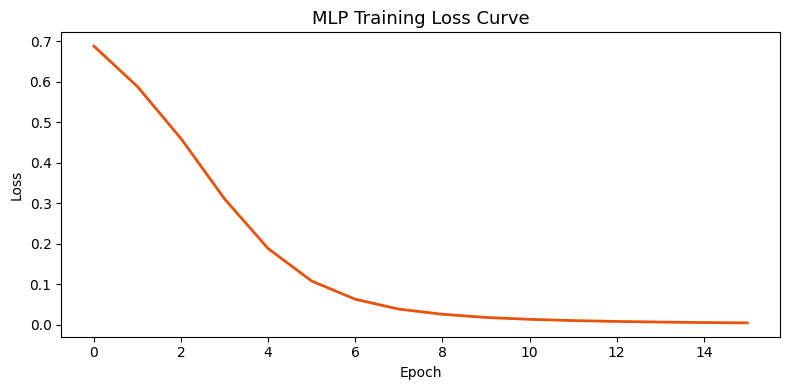

In [20]:
# training loss curve
plt.figure(figsize=(8, 4))
plt.plot(mlp_model.loss_curve_, color='#E8520A', linewidth=2)
plt.title('MLP Training Loss Curve', fontsize=13)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.tight_layout()
plt.show()

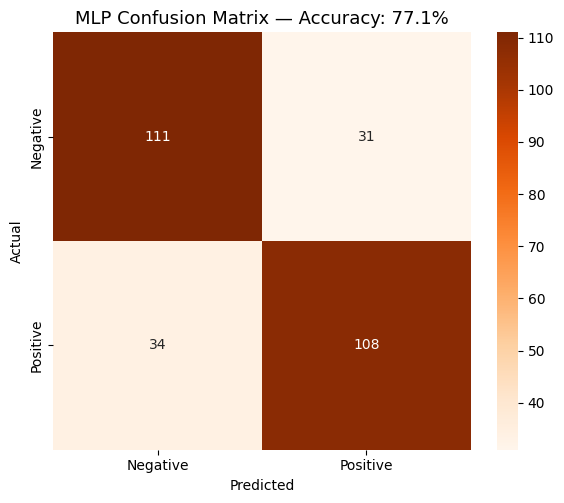

TN: 111  FP: 31
FN: 34  TP: 108


In [21]:
# confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(
    confusion_matrix(y_test, mlp_test_pred),
    annot=True, fmt='d', square=True, cmap='Oranges',
    xticklabels=['Negative', 'Positive'],
    yticklabels=['Negative', 'Positive']
)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'MLP Confusion Matrix — Accuracy: {mlp_test_acc*100:.1f}%', fontsize=13)
plt.tight_layout()
plt.show()

tn, fp, fn, tp = confusion_matrix(y_test, mlp_test_pred).ravel()
print(f'TN: {tn}  FP: {fp}')
print(f'FN: {fn}  TP: {tp}')

<a name='c5'></a>
# 5. Logistic Regression - Comparison Model

A second model is trained for comparison. This follows the approach shown in the class reference notebook from Module 10.

In [22]:
# train logistic regression on the same data
lr_model = LogisticRegression(solver='lbfgs', max_iter=1000)
lr_model.fit(X_train_cnt, y_train)

lr_val_pred  = lr_model.predict(X_val_cnt)
lr_test_pred = lr_model.predict(X_test_cnt)

lr_val_acc  = accuracy_score(y_val,  lr_val_pred)
lr_test_acc = accuracy_score(y_test, lr_test_pred)

print(f'LR Validation Accuracy : {lr_val_acc*100:.2f}%')
print(f'LR Test Accuracy       : {lr_test_acc*100:.2f}%')
print()
print('Classification Report (Test Set):')
print(classification_report(y_test, lr_test_pred, target_names=['Negative', 'Positive']))

LR Validation Accuracy : 77.11%
LR Test Accuracy       : 76.76%

Classification Report (Test Set):
              precision    recall  f1-score   support

    Negative       0.77      0.76      0.77       142
    Positive       0.76      0.77      0.77       142

    accuracy                           0.77       284
   macro avg       0.77      0.77      0.77       284
weighted avg       0.77      0.77      0.77       284



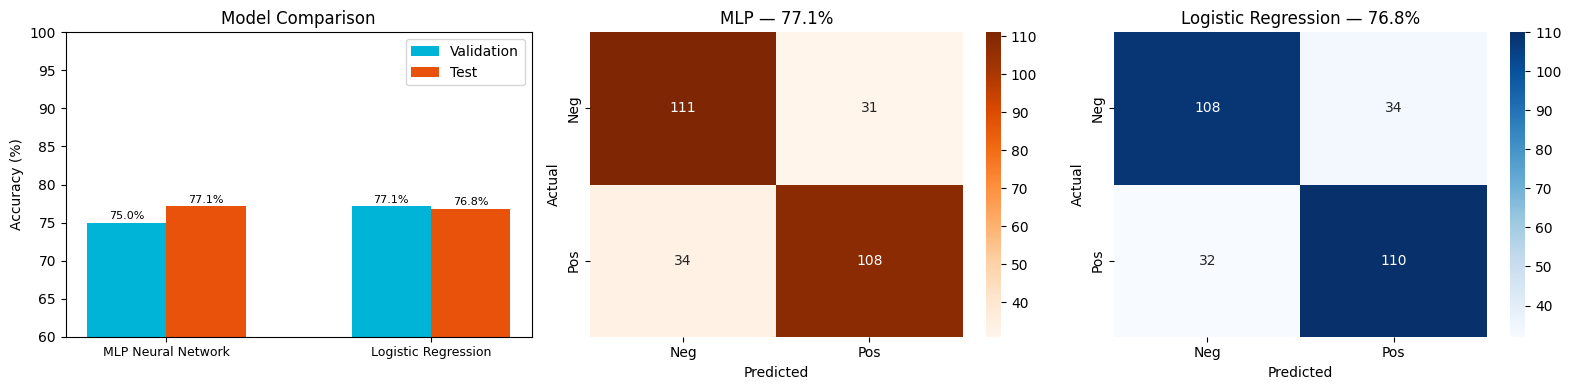

Best model: MLP Neural Network


In [23]:
# side by side comparison
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# bar chart
models     = ['MLP Neural Network', 'Logistic Regression']
val_accs   = [mlp_val_acc*100,  lr_val_acc*100]
test_accs  = [mlp_test_acc*100, lr_test_acc*100]
x = np.arange(len(models))
w = 0.3
axes[0].bar(x - w/2, val_accs,  w, label='Validation', color='#00B4D8')
axes[0].bar(x + w/2, test_accs, w, label='Test',       color='#E8520A')
axes[0].set_xticks(x)
axes[0].set_xticklabels(models, fontsize=9)
axes[0].set_ylabel('Accuracy (%)')
axes[0].set_title('Model Comparison')
axes[0].set_ylim(60, 100)
axes[0].legend()
for i, (v, t) in enumerate(zip(val_accs, test_accs)):
    axes[0].text(i - w/2, v + 0.5, f'{v:.1f}%', ha='center', fontsize=8)
    axes[0].text(i + w/2, t + 0.5, f'{t:.1f}%', ha='center', fontsize=8)

# MLP confusion matrix
sns.heatmap(confusion_matrix(y_test, mlp_test_pred), annot=True, fmt='d',
            cmap='Oranges', xticklabels=['Neg','Pos'], yticklabels=['Neg','Pos'], ax=axes[1])
axes[1].set_title(f'MLP — {mlp_test_acc*100:.1f}%')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

# LR confusion matrix
sns.heatmap(confusion_matrix(y_test, lr_test_pred), annot=True, fmt='d',
            cmap='Blues', xticklabels=['Neg','Pos'], yticklabels=['Neg','Pos'], ax=axes[2])
axes[2].set_title(f'Logistic Regression — {lr_test_acc*100:.1f}%')
axes[2].set_xlabel('Predicted')
axes[2].set_ylabel('Actual')

plt.tight_layout()
plt.show()

winner = 'MLP Neural Network' if mlp_test_acc >= lr_test_acc else 'Logistic Regression'
print(f'Best model: {winner}')

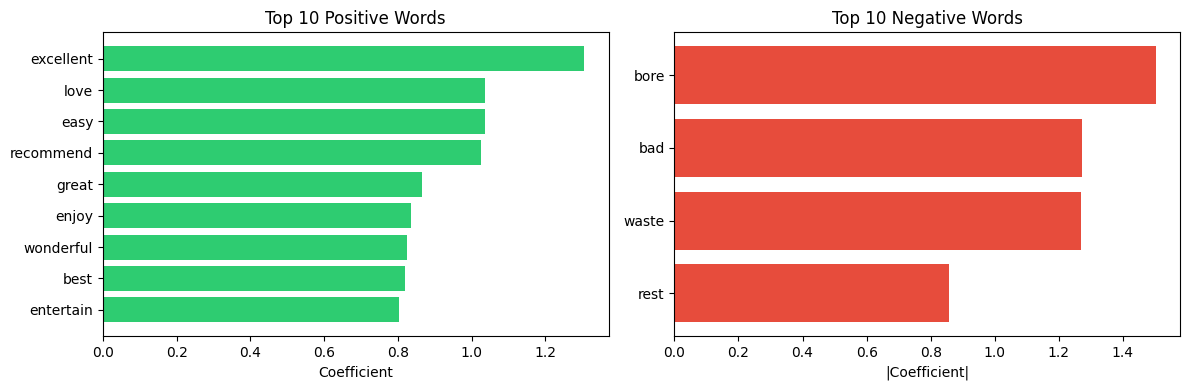

In [24]:
# word importance from logistic regression
class ValuedWord:
    def __init__(self, word, value):
        self.word  = word
        self.value = value

valuedWords = []
threshold   = 0.8

for i, j in zip(count_vect_model.get_feature_names_out(), lr_model.coef_[0]):
    if j > threshold or j < -threshold:
        valuedWords.append(ValuedWord(i, round(j, 3)))

pos_words = sorted([vw for vw in valuedWords if vw.value > 0], key=lambda x: x.value, reverse=True)[:10]
neg_words = sorted([vw for vw in valuedWords if vw.value < 0], key=lambda x: x.value)[:10]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.barh([vw.word for vw in pos_words], [vw.value for vw in pos_words], color='#2ECC71')
ax1.set_title('Top 10 Positive Words')
ax1.set_xlabel('Coefficient')
ax1.invert_yaxis()
ax2.barh([vw.word for vw in neg_words], [abs(vw.value) for vw in neg_words], color='#E74C3C')
ax2.set_title('Top 10 Negative Words')
ax2.set_xlabel('|Coefficient|')
ax2.invert_yaxis()
plt.tight_layout()
plt.show()

<a name='c6'></a>
# 6. Model Testing with New Entry Data

The function below takes any input sentence and classifies it as positive or negative.
This is based on the `on_button_clicked` function from the class reference notebook.
The MLP model is used for classification, with the logistic regression word weights used to explain which words contributed to the decision.

In [25]:
# prediction function using the MLP as primary model
wordsConsidered = []

def on_button_clicked(entrySen):
    global wordsConsidered
    wordsConsidered = []

    # clean and vectorise the input
    entered_words = clear(entrySen, True)
    encoded       = count_vect_model.transform([entrySen])
    scaled        = scaler.transform(encoded)

    # MLP prediction
    pred  = mlp_model.predict(scaled)[0]
    proba = mlp_model.predict_proba(scaled)[0]
    confidence = max(proba) * 100

    str_result = 'positive' if pred == 1 else 'negative'

    # word importance explanation from logistic regression
    for word in entered_words:
        for vw in valuedWords:
            if word == vw.word:
                wordsConsidered.append(vw)

    result1 = ''
    for c in wordsConsidered:
        result1 += '\n  ' + str(c.word) + ': ' + str(c.value)

    output = f'This sentence is {str_result}! (confidence: {confidence:.1f}%)'
    if result1:
        output += f'\nKey words considered:{result1}'
    return output


def on_words_considered_click():
    result = ''
    for c in wordsConsidered:
        result += '\n' + str(c.word) + ': ' + str(c.value)
    return result

In [26]:
# run inference on test sentences — both positive and negative
test_sentences = [
    'This book is absolutely amazing and I loved every single page of it',
    'Best purchase I have ever made highly recommend to everyone',
    'Excellent quality the story was captivating and the writing is superb',
    'Terrible book completely boring and a total waste of money',
    'Worst purchase I have ever made the plot makes no sense at all',
    'Very disappointed with this the writing is poor and it drags on forever',
    'It was okay nothing particularly special but not bad either',
]

print('=' * 65)
for sentence in test_sentences:
    print(f'\nInput: {sentence}')
    print(on_button_clicked(sentence))
    print('-' * 65)


Input: This book is absolutely amazing and I loved every single page of it
This sentence is positive! (confidence: 62.8%)
Key words considered:
  love: 1.037
-----------------------------------------------------------------

Input: Best purchase I have ever made highly recommend to everyone
This sentence is positive! (confidence: 63.4%)
Key words considered:
  best: 0.82
  recommend: 1.026
-----------------------------------------------------------------

Input: Excellent quality the story was captivating and the writing is superb
This sentence is positive! (confidence: 63.0%)
Key words considered:
  excellent: 1.306
-----------------------------------------------------------------

Input: Terrible book completely boring and a total waste of money
This sentence is negative! (confidence: 69.0%)
Key words considered:
  bore: -1.503
  waste: -1.269
-----------------------------------------------------------------

Input: Worst purchase I have ever made the plot makes no sense at all
This

In [36]:
# interactive input — type your own review
new_sen = input('Enter your review: ')
print(on_button_clicked(new_sen))
print(on_words_considered_click())

Enter your review: Excellent writing, highly recommend to everyone"
This sentence is positive! (confidence: 65.7%)
Key words considered:
  excellent: 1.306
  recommend: 1.026

excellent: 1.306
recommend: 1.026


<a name='c7'></a>
# 7. Ethical Considerations

**7.1 Labelling Bias**  
The labels in this dataset were assigned by the researchers who created it. Reviews that are genuinely neutral may have been incorrectly categorised as positive or negative, introducing noise into the training data (Turney, 2002).

**7.2 Class Balance**  
The dataset was designed with equal numbers of positive and negative reviews (1,000 each), which is good practice. An imbalanced dataset would cause the model to favour the majority class, reducing fairness for the minority class (Binns et al., 2018).

**7.3 Outlier Removal**  
Reviews with fewer than 3 words were removed. These are ambiguous and may not reliably express sentiment, so including them could bias the model.

**7.4 Deployment Risk**  
If used for automated content moderation, for example, hiding negative reviews without human review, the model could unfairly suppress legitimate customer feedback. This kind of system should support human decision-making, not replace it.

---

**References**  
Binns, R., Veale, M., Van Kleek, M., & Shadbolt, N. (2018). 'It's reducing a human being to a percentage': Perceptions of justice in algorithmic decisions. *Proceedings of the 2018 CHI Conference*, 1–14. https://doi.org/10.1145/3173574.3173951  
Blitzer, J., Dredze, M., & Pereira, F. (2007). Biographies, Bollywood, boom-boxes and blenders. *Proceedings of the 45th Annual Meeting of the ACL*, 187–205.  
Turney, P. D. (2002). Thumbs up or thumbs down? *Proceedings of the 40th Annual Meeting of the ACL*, 417–424.

In [28]:
# final summary
print('=' * 60)
print('  ISY503 Assessment 3 - Results Summary')
print('=' * 60)
print(f'  Dataset            : Amazon Books (Blitzer et al., 2007)')
print(f'  Total reviews      : {len(df)}')
print(f'  Train / Val / Test : 70% / 15% / 15%')
print(f'  Batch size         : {BATCH_SIZE}')
print('  ---')
print(f'  MLP Neural Network : Val {mlp_val_acc*100:.2f}% | Test {mlp_test_acc*100:.2f}%')
print(f'  Logistic Regression: Val {lr_val_acc*100:.2f}% | Test {lr_test_acc*100:.2f}%')
winner = 'MLP Neural Network' if mlp_test_acc >= lr_test_acc else 'Logistic Regression'
print(f'  Best model         : {winner}')
print('=' * 60)

  ISY503 Assessment 3 - Results Summary
  Dataset            : Amazon Books (Blitzer et al., 2007)
  Total reviews      : 1889
  Train / Val / Test : 70% / 15% / 15%
  Batch size         : 32
  ---
  MLP Neural Network : Val 75.00% | Test 77.11%
  Logistic Regression: Val 77.11% | Test 76.76%
  Best model         : MLP Neural Network
